# Exercises

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
import statsmodels.stats.proportion as smprop
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

---
## Exercise 4.1 Reliability: System lifetime

A device comprising of three components; "A", "B" and "C", is only functioning as long as all three components are functioning individually. The lifetime (in months) of the individual components are assumed to follow exponential distributions: The average lifetime of components of type "A" is 2 months, the average lifetime of components of type "B" is 3 months and the average lifetime of components of type "C" is 5 months. Hence we can describe the lifetime of each component type with the random variables, $X_A$, $X_B$ and $X_C$ that follow exponential distributions:

$$
X_A ∼ Exp(λ= 1/2) \\
X_B ∼ Exp(λ= 1/3) \\
X_C ∼ Exp(λ= 1/5) \\
$$

Describing the overall lifetime of devices is however not as straight forward.
We will therefore simulate the situation.

### a) 
Simulate a large number of devices (at least 1000 – go for 10000 or 100000 if your computer is up for it). For each device you will need to simulate the lifetimes of component A, B and C. Store this information in a DataFrame. In your simulation, how long does the first three devices stay functioning?

**Solution:**

In [2]:
sim_size = 1000000
A_life = 2
B_life = 3
C_life = 5
A = np.random.exponential(A_life, sim_size)
B = np.random.exponential(B_life, sim_size)
C = np.random.exponential(C_life, sim_size)
data = pd.DataFrame({'A': A, 'B': B, 'C': C})
# compute device lifetime as the time until the first component fails
data['device_lifetime'] = data[['A', 'B', 'C']].min(axis=1)
print('First 3 simulated device lifetimes (months):')
print(
    data['device_lifetime']
    .head(3)
    .to_string(
        index=False,
        float_format=lambda value: f'{value:.3f}'
    )
)


First 3 simulated device lifetimes (months):
1.849
0.306
0.183


### b) 
To check our simulation, compute the average lifetime of each component
type. Do these values match your expectations?

**Solution:**
to find the average lifetime of each component type, we can use the `mean()` function on each column of the DataFrame that contains the simulated lifetimes. we can compute the average lifetime for each component type as follows:

In [3]:
print(data.A.mean())
print(data.B.mean())
print(data.C.mean())


2.003160137848922
2.999097284792997
5.002752073988554


### c)
We now have a simulated dataset that we can play with. We can compute the
overall lifetime for each simulated device, and investigate how this simulated
random variable behaves:

For each device calculate the device lifetime and store this value in a new
column in your DataFrame. Make a histogram of the device lifetimes
(hence investigating the distribution of this simulated random variable).
(hint: consider how the random variable Y= "device lifetime" is a func-
tion of the three component lifetimes: is it the sum, the mean, the median,
the minimum, the maximum, the range or something else?)

**Solution:**

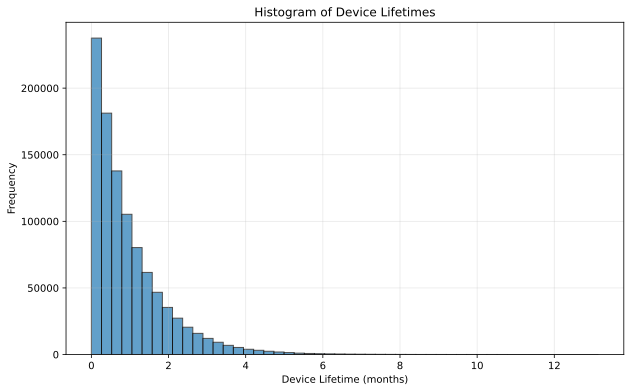

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(data['device_lifetime'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Histogram of Device Lifetimes')
plt.xlabel('Device Lifetime (months)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()


### d) 
Estimate the mean device lifetime from the simulated data.

**Solution:**


In [5]:
mean_device_lifetime = data['device_lifetime'].mean()
print(f'Mean device lifetime: {mean_device_lifetime:.4f} months')


Mean device lifetime: 0.9688 months


### e) 
Estimate the standard deviation of system lifetimes from the simulated data.

**Solution:**
we'll use the `std()` function on the column of the DataFrame that contains the device lifetimes to estimate the standard deviation. we can compute it as follows:

In [6]:
std_device_lifetime = data['device_lifetime'].std()
print(f'Standard deviation of device lifetimes: {std_device_lifetime:.4f} months')

Standard deviation of device lifetimes: 0.9676 months


### f) 
Estimate the probability that the system fails within 1 month.

**Solution:**
We can estimate the probability that the system fails within 1 month by calculating the proportion of simulated system lifetimes that are less than or equal to 1 month. This can be done as follows:

$$
P(Y ≤ 1) = \frac{\text{Number of devices with lifetime ≤ 1 month}}{\text{Total number of simulated devices}}
$$

Python:

In [11]:
prob_device_lifetime_leq_1 = 1 - (1 - stats.expon.cdf(1, scale=A_life)) * (1 - stats.expon.cdf(1, scale=B_life)) * (1 - stats.expon.cdf(1, scale=C_life))
print(f'Probability that device lifetime is 1 month or less: {prob_device_lifetime_leq_1 * 100:.4f}%')

Probability that device lifetime is 1 month or less: 64.4181%


### g)
Estimate the median system lifetime from the simulated data.

**Solution:**
We can estimate the median system lifetime by using the `median()` function on the column of the DataFrame that contains the device lifetimes. This can be computed as follows:

In [12]:
median_device_lifetime = data['device_lifetime'].median()
print(f'Median device lifetime: {median_device_lifetime:.4f} months')

Median device lifetime: 0.6720 months


### g)
Estimate the 10th percentile of system lifetimes from the simulated data.

**Solution:**
We can estimate the 10th percentile of system lifetimes by using the `quantile()` function on the column of the DataFrame that contains the device lifetimes, with the argument `0.1`. This can be computed as follows:

In [13]:
tenth_percentile_device_lifetime = data['device_lifetime'].quantile(0.1)
print(f'10th percentile of device lifetimes: {tenth_percentile_device_lifetime:.4f} months')

10th percentile of device lifetimes: 0.1025 months


### i) 
What seems to be the distribution of system lifetimes? (histogram etc)

**Solution:**
the distribution of system lifetimes seems to take on a logarithmic shape, with a long tail towards higher lifetimes. This is because the system lifetime is determined by the minimum of the three component lifetimes, which can lead to a skewed distribution. The histogram of the device lifetimes would likely show a concentration of values around lower lifetimes, with fewer devices having longer lifetimes.

using python we can take the survival curve of the system lifetimes and plot it to visualize the distribution. The survival curve can be calculated using the formula:

$$
S(t) = P(Y > t) = e^{-t \cdot (\frac{1}{A\_life} + \frac{1}{B\_life} + \frac{1}{C\_life})}
$$

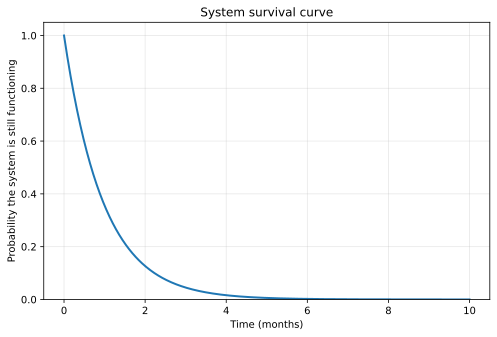

In [14]:
t = np.linspace(0, 10, 500)
system_survival = np.exp(-t * (1 / A_life + 1 / B_life + 1 / C_life))

plt.figure(figsize=(8, 5))
plt.plot(t, system_survival, linewidth=2)
plt.title('System survival curve')
plt.xlabel('Time (months)')
plt.ylabel('Probability the system is still functioning')
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.show()

---
## Exercise 4.5 Non-linear error propagation

Solve question (a)-(c) without using Python, but use Python to simulate in
question (d).

The pressure P, and the volume V of one mole of an ideal gas are related by
the equation PV= 8.31T, when P is measured in kilopascals, T is measured in
kelvins, and V is measured in liters.

### a) 
Assume that $P$ is measured to be $240.48$ kPa and $V$ to be $9.987$ L with known measurement errors (given as standard deviations): $0.03$ kPa and $0.002$ L. Estimate $T$ and find the uncertainty in the estimate.

**Solution:**

First we get an overveiw:
$$
P = 240.48 \pm 0.03 \\
V = 9.987 \pm 0.002
$$

$T = P \cdot V$ 

so we get:

$$
T = 240.48 \cdot 9.987 = 2403.8 \text{K}
$$

To find the uncertainty in the estimate of $T$, we can use error propagation. The formula for error propagation when multiplying two quantities is:

$$
\sigma^2_T \approx \left( \frac{\partial T}{\partial P} \right)^2 \sigma^2_P + \left( \frac{\partial T}{\partial V} \right)^2 \sigma^2_V
$$

finding the partial derivatives:
$$
\frac{\partial T}{\partial P} = V = 9.987 \\ 
\\
\frac{\partial T}{\partial V} = P = 240.48 \\
$$

giving us:
$$
\sigma^2_T \approx (9.987)^2 \cdot (0.03)^2 + (240.48)^2 \cdot (0.002)^2 \\
\sigma_T = \sqrt{(9.987 \cdot 0.03)^2 + (240.48 \cdot 0.002)^2} \approx 0.566647\text{K}
$$ 

therefore:
$$
T=2403.8 \pm 0.5666\text{K}
$$

### b)
Assume that $P$ is measured to be $240.48$kPa and $T$ to be $289.12$K with known measurement errors (given as standard deviations): $0.03$kPa and $0.02$K. Estimate V and find the uncertainty in the estimate.

**Solution:**
this is largely the same question as previous, but we need to rearrange the formula to get $V$ instead of $T$:

$$
V = \frac{T}{P} = \frac{289.12}{240.48} = 1.2022
$$

we re-compute the partial derivatives:
$$
\frac{\partial V}{\partial T} = \frac{1}{P} = \frac{1}{240.48} \\
\\
\frac{\partial V}{\partial P} = -\frac{T}{P^2} = -\frac{289.12}{240.48^2} \\
$$

giving us a new error propagation formula:
$$
\sigma_V \approx \sqrt{\left(\frac{\sigma_T}{P}\right)^2 + \left(\frac{T\,\sigma_P}{P^2}\right)^2}
$$

using it:
$$
\sigma_V \approx \sqrt{\left(\frac{0.02}{240.48}\right)^2 + \left(\frac{289.12\cdot 0.03}{240.48^2}\right)^2}
= 0.000171498
$$

yielding:
$$
V = 1.2022 \pm 0.0001715
$$

### c)
Assume that $V$ is measured to be $9.987$ L and $T$ to be $289.12$ K with known measurement errors (given as standard deviations): $0.002$ L and $0.02$ K. Estimate $P$ and find the uncertainty in the estimate.

**Solution:**
once more the same question but rearranged to get $P$ instead of $T$ or $V$:
$$
P = \frac{T}{V} = \frac{289.12}{9.987} = 28.9496 
$$  

we re-compute the partial derivatives:
$$
\frac{\partial P}{\partial T} = \frac{1}{V} = \frac{1}{9.987} \\
\\
\frac{\partial P}{\partial V} = -\frac{T}{V^2} = -\frac{289.12}{9.987^2} \\
$$
giving us a new error propagation formula:
$$
\sigma_P \approx \sqrt{\left(\frac{\sigma_T}{V}\right)^2 + \left(\frac{T\,\sigma_V}{V^2}\right)^2}
$$
using it:
$$
\sigma_P \approx \sqrt{\left(\frac{0.02}{9.987}\right)^2 + \left(\frac{289.12\cdot 0.002}{9.987^2}\right)^2}
= 0.00613360 
$$

yielding:
$$
P = 28.9496 \pm 0.0061336
$$

### d)
Try to answer one or more of these questions by simulation (assume that the errors are normally distributed).

**Solution:**
we'll solve all 3 simulations using python, yields practically identical results to the above calculations:

In [23]:
k = 1000000

T_sim = stats.norm.rvs(loc=289.12, scale=0.02, size=k)
P_sim = stats.norm.rvs(loc=240.48, scale=0.03, size=k)
V_sim = stats.norm.rvs(loc=9.987,  scale=0.002, size=k)

# part a: T = P * V
T_derived = P_sim * V_sim
print(np.std(T_derived, ddof=1))

# part b: V = T / P
V_derived = T_sim / P_sim
print(np.std(V_derived, ddof=1))

# part c: P = T / V
P_derived = T_sim / V_sim
print(np.std(P_derived, ddof=1))

0.5667860012023131
0.00017148653751419672
0.0061381931256750556


---
## 2.15 Bivariate normal

### a)
In the bivariate normal distribution (see Example 2.73), show that if $\Sigma$ is a diagonal matrix then $(X_1, X_2)$ are also independent and follow univariate normal distributions.

**Solution:**

From the notes: "in general zero correlation does not imply independence, but for the multivariate normal it does."

$\Sigma$ being diagonal means it takes the form:
$$
\Sigma = \begin{bmatrix}\sigma_1^2 & 0 \\ 0 & \sigma_2^2 \end{bmatrix}
$$

The off-diagonal entries are the covariances, implying $\text{Cov}(X_1, X_2) = 0$.

By the independence theorem for the multivariate normal: if $\mathbf{Y} \sim N(\boldsymbol{\mu}, \Sigma)$ and $\text{Cov}[\mathbf{Y}_1, \mathbf{Y}_2] = 0$, then $\mathbf{Y}_1$ and $\mathbf{Y}_2$ are independent.

Since the marginals of a multivariate normal are always univariate normal, it follows that $X_1 \sim N(\mu_1, \sigma_1^2)$ and $X_2 \sim N(\mu_2, \sigma_2^2)$ are independent.

### b)
Assume that $Z_1$ and $Z_2$ are independent standard normal random variables. Now let $X$ and $Y$ be defined by

$$
X = a_{11}Z_1 + c_1 \\
Y = a_{12}Z_1 + a_{22}Z_2 + c_2
$$

i.e. in matrix form:

$$
\begin{pmatrix} X \\ Y \end{pmatrix} = \begin{pmatrix} a_{11} & 0 \\ a_{12} & a_{22} \end{pmatrix} \begin{pmatrix} Z_1 \\ Z_2 \end{pmatrix} + \begin{pmatrix} c_1 \\ c_2 \end{pmatrix}
$$

Show that an appropriate choice of $a_{11}, a_{12}, a_{22}, c_1, c_2$ can give any bivariate normal distribution for the random vector $(X, Y)$, i.e. find $a_{11}, a_{12}, a_{22}, c_1, c_2$ as a function of $\mu_X, \mu_Y$ and the elements of $\Sigma$.

Note that $\Sigma_{ij} = \text{Cov}(X_i, X_j)$ (i.e. here $\Sigma_{12} = \Sigma_{21} = \text{Cov}(X, Y)$), and that any linear combination of random normal variables will result in a random normal variable.

**Solution:**

From general definition in my notes:

$Y = A Z + b$ with $E[Y] = b$ and $V[Y] = A A^T$. 

translating this to the problem we substitute some symbols:
$$
b = \mu \\
A A^T = \Sigma
$$

this is made trivial due to the fact that $E[Z_1] = E[Z_2] = 0$:

$$
E[X] = c_1 = \mu_X \\
E[Y] = c_2 = \mu_Y
$$

computing the covariance matrix:
$$
A A^T = \begin{bmatrix} a_{11} & 0 \\ a_{12} & a_{22} \end{bmatrix} \begin{bmatrix} a_{11} & a_{12} \\ 0 & a_{22} \end{bmatrix} = \begin{bmatrix} a_{11}^2 & a_{11}a_{12} \\ a_{11}a_{12} & a_{12}^2 + a_{22}^2 \end{bmatrix}
$$

then matching to $\Sigma$:
$$
\Sigma = \begin{bmatrix} \sigma_X^2 & \sigma_{X Y} \\ \sigma_{X Y} & \sigma_Y^2 \end{bmatrix}
$$ 

Reading off entries:
$$
a_{11}^2 = \sigma_X^2 \implies a_{11} = \sigma_X \\
a_{11}a_{12} = \sigma_{X Y} \implies a_{12} = \frac{\sigma_{X Y}}{\sigma_X} \\
a_{12}^2 + a_{22}^2 = \sigma_Y^2 \implies a_{22} = \sqrt{\sigma_Y^2 - \frac{\sigma_{X Y}^2}{\sigma_X^2}}
$$

Since any linear combination of normals is normal (stated in the problem), $(X,Y)$ is bivariate normal with any valid $\mu$ and $\Sigma$ by choosing these parameters.

### c)
Use the result to simulate 1000 realizations of a bivariate normal random variable with

$$
\mu = \begin{pmatrix} 1 \\ 2 \end{pmatrix}, \quad \Sigma = \begin{pmatrix} 1 & 1 \\ 1 & 2 \end{pmatrix}
$$

and make a scatter plot of the bivariate random variable.

**Solution:**
it can be solved manually with python as shown below, or scipy can be used direcrlty: `samples2 = stats.multivariate_normal(mean=mu, cov=Sigma).rvs(1000)` which is a lot simpler.

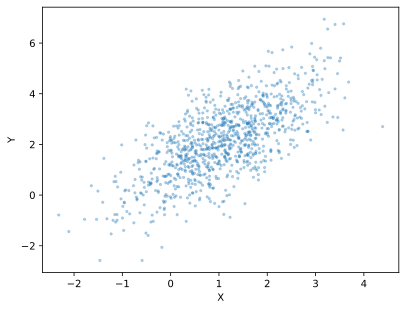

In [30]:
sim_size = 1000

mu = np.array([1, 2])

# read off from Sigma = [[1,1],[1,2]]
sigma_X = 1          # sqrt(sigma_X^2) = sqrt(1)
sigma_XY = 1
sigma_Y = np.sqrt(2)

a11 = sigma_X
a12 = sigma_XY / sigma_X
a22 = np.sqrt(sigma_Y**2 - (sigma_XY**2 / sigma_X**2))

A = np.array([[a11, 0],
              [a12, a22]])

Z = stats.norm.rvs(size=(2, sim_size))
samples = A @ Z + mu.reshape(2, 1)

plt.scatter(samples[0], samples[1], alpha=0.3, s=5)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

---
## Exercise 9.1 Proof of Theorem 9.14

### a)
Prove Theorem 9.14, using the definition in equation (9-38).

**Theorem 9.14 — Independence of normal random variables:**
If $\mathbf{Y} = [\mathbf{Y}_1^T, \mathbf{Y}_2^T]^T \sim N(\boldsymbol{\mu}, \Sigma)$, and
$$\text{Cov}[\mathbf{Y}_1, \mathbf{Y}_2] = \mathbf{0}$$
then $\mathbf{Y}_1$ and $\mathbf{Y}_2$ are independent.

**Equation (9-38):**
$$f_Y(\mathbf{y}) = \frac{1}{(2\pi)^{n/2}\sqrt{|\Sigma|}} e^{-\frac{1}{2}(\mathbf{y}-\boldsymbol{\mu})^T \Sigma^{-1} (\mathbf{y}-\boldsymbol{\mu})}$$


**Solution:**
Since $\text{Cov}[\mathbf{Y}_1, \mathbf{Y}_2] = \mathbf{0}$, $\Sigma$ is block diagonal:
$$\Sigma = \begin{pmatrix} \Sigma_{11} & \mathbf{0} \\ \mathbf{0} & \Sigma_{22} \end{pmatrix}$$

For block diagonal matrices, $\Sigma^{-1}$ and $|\Sigma|$ also factorize, so the exponent in (9-38) splits into two independent terms. The joint pdf therefore factorizes:
$$f_Y(\mathbf{y}) = f_{Y_1}(\mathbf{y}_1) \cdot f_{Y_2}(\mathbf{y}_2)$$

which is the definition of independence, hence $\mathbf{Y}_1$ and $\mathbf{Y}_2$ are independent. $\square$

---
## Exercise 9.3 Proof of Eq. (9-50)

### a)
Prove that the row sums of $A$ in (9-49) are equal to zero, i.e. that $A\mathbf{1} = \mathbf{0}$.

$$A = \begin{bmatrix} 1-\frac{1}{n} & -\frac{1}{n} & \cdots & -\frac{1}{n} \\ -\frac{1}{n} & 1-\frac{1}{n} & \ddots & \vdots \\ \vdots & \ddots & \ddots & -\frac{1}{n} \\ -\frac{1}{n} & \cdots & -\frac{1}{n} & 1-\frac{1}{n} \end{bmatrix} = I - \frac{1}{n}E$$

**Solution:**

### b)
Prove Eq. (9-48):
$$\mathbf{r} = \begin{bmatrix} Z_1 - \bar{Z} \\ \vdots \\ Z_n - \bar{Z} \end{bmatrix} = A\mathbf{Z}, \quad \mathbf{Z} \sim N(\mathbf{0}, I)$$

**Solution:**

### c)
Prove Eq. (9-50):
$$AA^T = A^2 = A$$

**Solution:**

---
## Exercise 9.2 Independence and correlation

### a)
Simulate $Y_1$, $X$ and $Y_2$ using the setting in Example 9.15.

**Example 9.15:** Let $Y_1 \sim N(0,1)$ and let $P(X=-1) = P(X=1) = \frac{1}{2}$ independent
of $Y_1$, and define $Y_2 = XY_1$. Then the marginal distribution of $Y_2$ is the standard
normal and
$$\text{Cov}[Y_1, Y_2] = \text{Cov}[Y_1, XY_1] = E[Y_1 XY_1] = E[X]E[Y_1^2] = E[X]V[Y_1] = E[X] = 0$$
hence no correlation, but clearly the variables are not independent, as knowledge of
$Y_1$ limits the number of possible outcomes of $Y_2$ to two possible values ($Y_1$ or $-Y_1$).

**Solution:**

### b)
Check that both $Y_1$ and $Y_2$ are normal, and plot $Y_2$ as a function of $Y_1$.

**Solution:**

### c)
Calculate the correlation between $Y_1$ and $Y_2$ and plot $Y_2$ as a function of $Y_1$, and comment on the results.

**Solution:**